### PSMNIST Classification with S4


In [4]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from psmnist_task import PSMNISTTask
from src.train_utils.trainer import Trainer

## Configuration Setup

Using unified block factory from src.utils.block_factory.
This provides consistent block configuration across all experiments.


In [3]:
from src.utils.block_factory import make_s4_block_cfg_ctor

## Hyperparameters & Data Paths

In [5]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "psmnist" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/psmnist_s4_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 2,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",
}

print(f"Data root: {data_root}")
print(f"Save directory: {args['save_dir']}")

Data root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/psmnist/data
Save directory: ./runs/psmnist_s4_task


## Model Setup & Device Selection

Create the S4 block configuration constructor and select the appropriate device.
The configuration is **model-agnostic** - only the `kind="s4"` parameter
makes this an S4 model instead of LMU.


In [7]:
args["block_cfg_ctor"] = make_s4_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS (Apple Silicon)")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU (slower)")

Using MPS (Apple Silicon)


## Training

Initialize the task, apply MPS optimizations if available, and train the model.
The `Trainer` handles:
- Model building from the block config
- Training loop with progress bars
- Validation and early stopping
- Checkpoint saving
- Mixed precision training (AMP)


In [ ]:
task = PSMNISTTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

print("\n" + "="*60)
print("INITIALIZING S4 MODEL FOR PSMNIST")
print("="*60)

trainer = Trainer(args=args, task=task)

print("\nStarting training...")
best_metric, ckpt_path = trainer.fit()

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Best {trainer.early_key}: {best_metric:.4f}")
print(f"Checkpoint saved: {ckpt_path}")
print("="*60 + "\n")

In [8]:
from src.utils.visualization import plot_classification_history as plot_history

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
Loaded checkpoint from epoch 44
Val metrics: {'loss': 0.2821985372066498, 'time_s': 16.787201584000286, 'acc': 0.9166}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


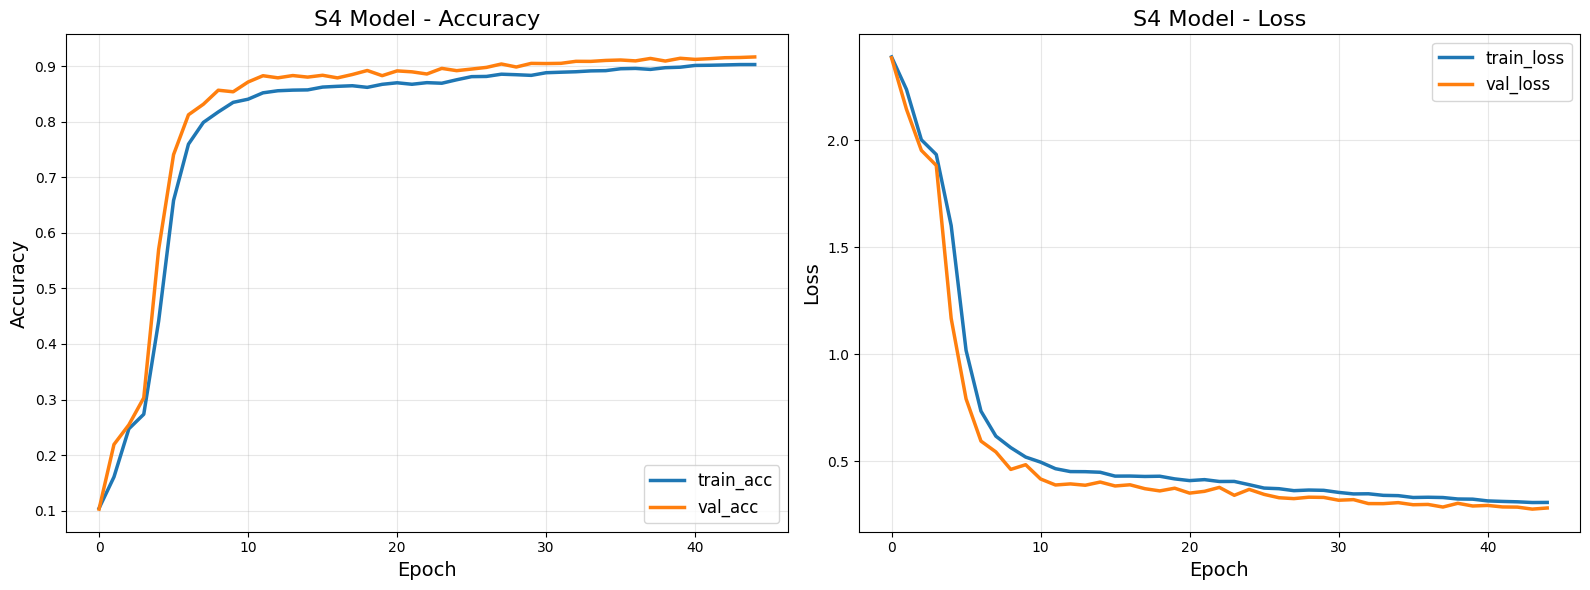

In [9]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=PSMNISTTask(),
)

history = trainer.history

plot_history(history, model_name="S4")

## Evaluation

Load the best checkpoint and evaluate on the test set.
This provides the final accuracy metric for the S4 model on PSMNIST.


Evaluating best model on test set...
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
Loaded checkpoint from epoch 44
Val metrics: {'loss': 0.2821985372066498, 'time_s': 16.787201584000286, 'acc': 0.9166}
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)

✅ Test results saved to: runs/psmnist_s4_task/test_results.json

   Test Accuracy: 0.9166 (91.66%)
   Test Loss: 0.2822

TEST SET RESULTS
Overall accuracy: 0.9166
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_1                   : 0.984
02. class_0                   : 0.964
03. class_6                   : 0.948
04. class_4                   : 0.929
05. class_7                   : 0.924
06. class_9                   : 0.909
07. clas

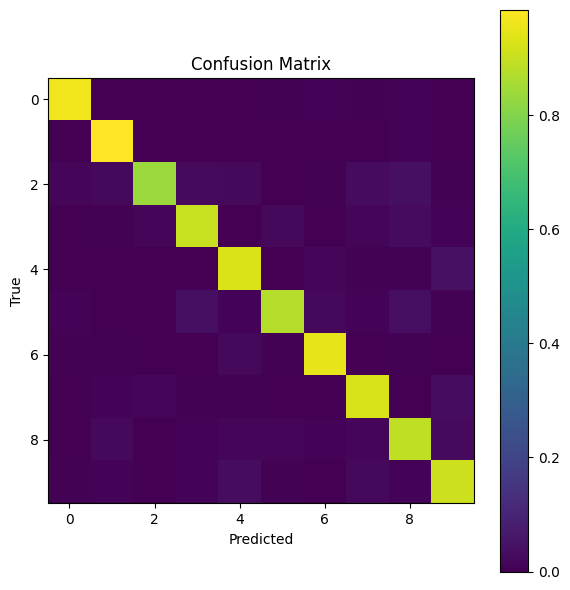

In [12]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

print("Evaluating best model on test set...")
logits_test, labels_test = evaluate_best_model(
    args=args,
    task=PSMNISTTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Changes in dataset length

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


for frac in [0.1, 0.25, 0.5]:
    print(f"\n Training with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/psmnist_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=PSMNISTTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="S4")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=PSMNISTTask(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )